Original Notebook:

https://www.kaggle.com/code/cdeotte/gemma2-9b-it-cv-0-945

# Gemma2-2B-it - CV 0.945
This notebook is a follow-up of my `Deberta-v3-xsmall` starter notebook [here][1], `ModernBERT-Large` notebook [here][4], and `Ettin-Encoder-1B` notebook [here][6]. This notebook demonstrates how to make an inference only notebook for quick submission to Kaggle's MAP comp! And this notebook teaches two new ideas.

## New Lessons
This notebook demonstrates some new lessons compared to my previous notebooks.
* We can use bigger model `9B > 1B` and achieve a better CV/LB score!
* We can use LORA adapter during train and infer for efficient LLM weight updates.

## Training Tips
This model has `9B` parameters compared with `Ettin-Encoder-1B` which has `1B` parameters. This model is difficult to train on most GPUs. For efficient training, we need to use LORA or QLORA. Eventually I will make a LORA/QLORA notebook for this competition. In the meanwhile, you can view my LORA/QLORA notebook from previous competition [here][7] where we train `Gemma2-9B-it`.

Also consider adding `DataCollatorWithPadding` to make training and inference more efficient. This suggestion was made by Eli Haciyev [here][5] and would make training and inference faster and more efficient.

## Training Log
Using 1xA100 with 80GB VRAM we can load model in bf16 and train with LORA adapter `rank=8`, `batch size=8`, and `learning rate=1e-4`. Training took 2 hours and 45 minutes with the following log:

| Epoch | Training Loss | Validation Loss | Map@3   |
|-------|---------------|------------------|---------|
| 1     | 0.536400      | 0.441546         | 0.925409 |
| 2     | 0.410500      | 0.434120         | 0.936285 |
| 3     | 0.312000      | 0.494922         | 0.945254 |

## How To Make Inference Notebook
**STEP 1**: We run my Deberta starter notebook either on Kaggle or on our local computer. We pick any model to train. This time I tried `google/gemma-2-9b-it` (from HF [here][3]) and achieved CV 0.945 in 3 epochs (CV score is actually a 20% hold out validation score). After we are happy with validation score, we **re-train the model using 100% train data**!

**STEP 2**: We upload the saved model to a Kaggle dataset. (I uploaded [here][2]). Then we attach Kaggle dataset to this notebook and we run this notebook which only infers the model without training. This makes a quick submission notebook for Kaggle's MAP comp!

**Note:** We infer on Kaggle with `bf16=False` and `fp16=True` because Kaggle's T4 does not support `bf16`. Using half precision accelerates inference!

[1]: https://www.kaggle.com/code/cdeotte/deberta-starter-cv-0-930/notebook
[2]: https://www.kaggle.com/datasets/cdeotte/gemma2-9b-it-cv945
[3]: https://huggingface.co/google/gemma-2-9b-it
[4]: https://www.kaggle.com/code/cdeotte/modernbert-large-cv-0-938
[5]: https://www.kaggle.com/code/cdeotte/modernbert-large-cv-0-938/comments#3250156
[6]: https://www.kaggle.com/code/cdeotte/ettin-encoder-1b-cv-0-943
[7]: https://www.kaggle.com/code/cdeotte/16th-place-train-1-of-3

# Config

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"

VER=1
#model_name = "google/gemma-2-9b-it"
model_name = "/kaggle/input/gemma2-9b-it-cv945"
EPOCHS = 2

DIR = f"ver_{VER}"
os.makedirs(DIR, exist_ok=True)

# Load Train

In [2]:
import pandas as pd, numpy as np
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
train = pd.read_csv('/kaggle/input/map-charting-student-math-misunderstandings/train.csv')
train.Misconception = train.Misconception.fillna('NA')
train['target'] = train.Category+":"+train.Misconception
train['label'] = le.fit_transform(train['target'])
target_classes = le.classes_
n_classes = len(target_classes)
print(f"Train shape: {train.shape} with {n_classes} target classes")
train.head()

Train shape: (36696, 9) with 65 target classes


,row_id,QuestionId,QuestionText,MC_Answer,StudentExplanation,Category,Misconception,target,label
0,0,31772,What fraction of the shape is not shaded? Give...,\( \frac{1}{3} \),0ne third is equal to tree nineth,True_Correct,NA,True_Correct:NA,37
1,1,31772,What fraction of the shape is not shaded? Give...,\( \frac{1}{3} \),1 / 3 because 6 over 9 is 2 thirds and 1 third...,True_Correct,NA,True_Correct:NA,37
2,2,31772,What fraction of the shape is not shaded? Give...,\( \frac{1}{3} \),"1 3rd is half of 3 6th, so it is simplee to un...",True_Neither,NA,True_Neither:NA,64
3,3,31772,What fraction of the shape is not shaded? Give...,\( \frac{1}{3} \),1 goes into everything and 3 goes into nine,True_Neither,NA,True_Neither:NA,64
4,4,31772,What fraction of the shape is not shaded? Give...,\( \frac{1}{3} \),1 out of every 3 isn't coloured,True_Correct,NA,True_Correct:NA,37


# Powerful Feature Engineer
We engineer one feature which we will use when formatting the input text for our LLM. Consider using more feature engineering and/or modifying the input text to our LLM. There is a discussion about this feature [here][1]

[1]: https://www.kaggle.com/competitions/map-charting-student-math-misunderstandings/discussion/589400

In [3]:
idx = train.apply(lambda row: row.Category.split('_')[0],axis=1)=='True'
correct = train.loc[idx].copy()
correct['c'] = correct.groupby(['QuestionId','MC_Answer']).MC_Answer.transform('count')
correct = correct.sort_values('c',ascending=False)
correct = correct.drop_duplicates(['QuestionId'])
correct = correct[['QuestionId','MC_Answer']]
correct['is_correct'] = 1

train = train.merge(correct, on=['QuestionId','MC_Answer'], how='left')
train.is_correct = train.is_correct.fillna(0)

# Question EDA
The train.csv has 15 multiple choice math questions. Below we display each of the questions and the 4 MC choices. The choices are sorted from (A) most popular selected to (D) least popular selected.

In [4]:
from IPython.display import display, Math, Latex

# GET ANSWER CHOICES
tmp = train.groupby(['QuestionId','MC_Answer']).size().reset_index(name='count')
tmp['rank'] = tmp.groupby('QuestionId')['count'].rank(method='dense', ascending=False).astype(int) - 1
tmp = tmp.drop('count',axis=1)
tmp = tmp.sort_values(['QuestionId','rank'])

# DISPLAY QUESTION AND ANSWER CHOICES
Q = tmp.QuestionId.unique()
for q in Q:
    question = train.loc[train.QuestionId==q].iloc[0].QuestionText
    choices = tmp.loc[tmp.QuestionId==q].MC_Answer.values
    labels="ABCD"
    choice_str = " ".join([f"({labels[i]}) {choice}" for i, choice in enumerate(choices)])
    
    print()
    display(Latex(f"QuestionId {q}: {question}") )
    display(Latex(f"MC Answers: {choice_str}"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

...

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

# Train with Transformers
We will train our Gemma2 model using Transformers library.

In [5]:
import torch
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split
from datasets import Dataset
import numpy as np

tokenizer = AutoTokenizer.from_pretrained(model_name)
MAX_LEN = 256

# Tokenize Train Data
First we must tokenizer our data. Before we can tokenizer, we need to decide how to convert the multiple text columns into a single prompt. We will show our model the `QuestionText`, then the `MC_Answer` response, then use our `powerful feature engineer` to say whether this answer is `correct or incorrect`. Finally we will show our LLM the `StudentExplanation`.

Consider changing the prompt below. Modifying the prompt can significantly improve our CV score!

In [6]:
def format_input(row):
    x = "Yes"
    if not row['is_correct']:
        x = "No"
    return (
        f"Question: {row['QuestionText']}\n"
        f"Answer: {row['MC_Answer']}\n"
        f"Correct? {x}\n"
        f"Student Explanation: {row['StudentExplanation']}"
    )

train['text'] = train.apply(format_input,axis=1)
print("Example prompt for our LLM:")
print()
print( train.text.values[0] )

Example prompt for our LLM:

Question: What fraction of the shape is not shaded? Give your answer in its simplest form. [Image: A triangle split into 9 equal smaller triangles. 6 of them are shaded.]
Answer: \( \frac{1}{3} \)
Correct? Yes
Student Explanation: 0ne third is equal to tree nineth


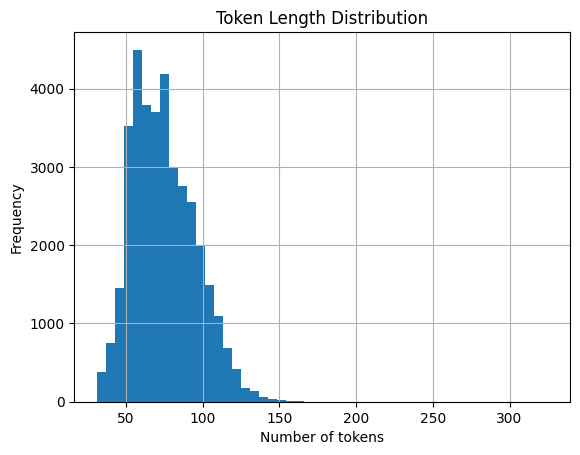

In [7]:
lengths = [len(tokenizer.encode(t, truncation=False)) for t in train["text"]]
import matplotlib.pyplot as plt

plt.hist(lengths, bins=50)
plt.title("Token Length Distribution")
plt.xlabel("Number of tokens")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

In [8]:
L = (np.array(lengths)>MAX_LEN).sum()
print(f"There are {L} train sample(s) with more than {MAX_LEN} tokens")
np.sort( lengths )

There are 1 train sample(s) with more than 256 tokens


array([ 31,  31,  31, ..., 195, 231, 325])

# Create 20% Validation Subset

In [9]:
# Split into train and validation sets
train_df, val_df = train_test_split(train, test_size=0.2, random_state=42)

# Convert to Hugging Face Dataset
COLS = ['text','label']
train_ds = Dataset.from_pandas(train_df[COLS])
val_ds = Dataset.from_pandas(val_df[COLS])

In [10]:
# Tokenization function
def tokenize(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=256)

train_ds = train_ds.map(tokenize, batched=True)
val_ds = val_ds.map(tokenize, batched=True)

# Set format for PyTorch
columns = ['input_ids', 'attention_mask', 'label']
train_ds.set_format(type='torch', columns=columns)
val_ds.set_format(type='torch', columns=columns)

Map:   0%|          | 0/29356 [00:00<?, ? examples/s]

Map:   0%|          | 0/7340 [00:00<?, ? examples/s]

# Initialize Model
Let's initialize and train our model with HuggingFace trainer. We also define a custom metric of MAP@3 which is the competition metric.

In [11]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

model = AutoModelForSequenceClassification.from_pretrained(
    "/kaggle/input/gemma2-9b-it-bf16",
    num_labels=n_classes,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)

2025-07-24 13:40:06.922391: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753364407.139076      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753364407.200368      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Some weights of Gemma2ForSequenceClassification were not initialized from the model checkpoint at /kaggle/input/gemma2-9b-it-bf16 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


# Load PEFT Adapter and Infer
We trained this model with a LORA adapter. So now during inference we load the saved LORA adapter to wrap the pretrained `Gemma2-9B-it` base model. (To learn how to train with LORA/QLORA, see previous competition notebook [here][1])

[1]: https://www.kaggle.com/code/cdeotte/16th-place-train-1-of-3

In [12]:
from peft import PeftModel
model = PeftModel.from_pretrained(model, model_name)

/usr/local/lib/python3.11/dist-packages/peft/config.py:165: UserWarning: Unexpected keyword arguments ['qalora_group_size', 'use_qalora'] for class LoraConfig, these are ignored. This probably means that you're loading a configuration file that was saved using a higher version of the library and additional parameters have been introduced since. It is highly recommended to upgrade the PEFT version before continuing (e.g. by running `pip install -U peft`).
  warnings.warn(


In [13]:
training_args = TrainingArguments(
    output_dir = f"./{DIR}",
    do_train=True,
    do_eval=True,
    eval_strategy="steps",
    save_strategy="steps", #no for no saving 
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    logging_dir="./logs",
    logging_steps=50,
    save_steps=200,
    eval_steps=200,
    save_total_limit=1,
    metric_for_best_model="map@3",
    greater_is_better=True,
    load_best_model_at_end=True,
    report_to="none",
    bf16=False, # TRAIN WITH BF16 IF LOCAL GPU IS NEWER GPU          
    fp16=True, # INFER WITH FP16 BECAUSE KAGGLE IS T4 GPU
)

In [14]:
# CUSTOM MAP@3 METRIC

from sklearn.metrics import average_precision_score

def compute_map3(eval_pred):
    logits, labels = eval_pred
    probs = torch.nn.functional.softmax(torch.tensor(logits), dim=-1).numpy()
    
    top3 = np.argsort(-probs, axis=1)[:, :3]  # Top 3 predictions
    match = (top3 == labels[:, None])

    # Compute MAP@3 manually
    map3 = 0
    for i in range(len(labels)):
        if match[i, 0]:
            map3 += 1.0
        elif match[i, 1]:
            map3 += 1.0 / 2
        elif match[i, 2]:
            map3 += 1.0 / 3
    return {"map@3": map3 / len(labels)}

In [15]:
# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    compute_metrics=compute_map3,
)

#trainer.train()

/tmp/ipykernel_36/661334471.py:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


# Save Model
This is how to save the files we need to upload to a Kaggle dataset for inference. If we train with LORA/QLORA adapter then this save command efficiently only saves the LORA adapter. (i.e. the same LORA adapter that this inference notebook is using).

In [16]:
#trainer.save_model(f"ver_{VER}")      
#tokenizer.save_pretrained(f"ver_{VER}")

# Load and Predict Test 
We load test data, then engineer our powerful feature, then create prompt, then tokenize. Finally we infer test and generate probabilities for all 65 multi-classes.

In [17]:
test = pd.read_csv('/kaggle/input/map-charting-student-math-misunderstandings/test.csv')
print( test.shape )
test.head()

(3, 5)


,row_id,QuestionId,QuestionText,MC_Answer,StudentExplanation
0,36696,31772,What fraction of the shape is not shaded? Give...,\( \frac{1}{3} \),"I think that 1/3 is the answer, as it's the si..."
1,36697,31772,What fraction of the shape is not shaded? Give...,\( \frac{3}{6} \),i think this answer is because 3 triangles are...
2,36698,32835,Which number is the greatest?,\( 6.2 \),because the 2 makes it higher than the others.


In [18]:
test = test.merge(correct, on=['QuestionId','MC_Answer'], how='left')
test.is_correct = test.is_correct.fillna(0)

test['text'] = test.apply(format_input,axis=1)

test.head()

,row_id,QuestionId,QuestionText,MC_Answer,StudentExplanation,is_correct,text
0,36696,31772,What fraction of the shape is not shaded? Give...,\( \frac{1}{3} \),"I think that 1/3 is the answer, as it's the si...",1.0,Question: What fraction of the shape is not sh...
1,36697,31772,What fraction of the shape is not shaded? Give...,\( \frac{3}{6} \),i think this answer is because 3 triangles are...,0.0,Question: What fraction of the shape is not sh...
2,36698,32835,Which number is the greatest?,\( 6.2 \),because the 2 makes it higher than the others.,1.0,Question: Which number is the greatest?\nAnswe...


In [19]:
ds_test = Dataset.from_pandas(test[['text']])
ds_test = ds_test.map(tokenize, batched=True)

predictions = trainer.predict(ds_test)
probs = torch.nn.functional.softmax(torch.tensor(predictions.predictions), dim=1).numpy()

Map:   0%|          | 0/3 [00:00<?, ? examples/s]

# Create Submission CSV
We create submission.csv by converting our top3 test preds into their class names

In [20]:
# Get top 3 predicted class indices
top3 = np.argsort(-probs, axis=1)[:, :3]   # shape: [num_samples, 3]

# Decode numeric class indices to original string labels
flat_top3 = top3.flatten()
decoded_labels = le.inverse_transform(flat_top3)
top3_labels = decoded_labels.reshape(top3.shape)

# Join 3 labels per row with space
joined_preds = [" ".join(row) for row in top3_labels]

# Save submission
sub = pd.DataFrame({
    "row_id": test.row_id.values,
    "Category:Misconception": joined_preds
})
sub.to_csv("submission.csv", index=False)
sub.head()

,row_id,Category:Misconception
0,36696,True_Correct:NA True_Neither:NA True_Misconcep...
1,36697,False_Misconception:WNB False_Neither:NA True_...
2,36698,True_Neither:NA True_Correct:NA True_Misconcep...


Result:

Score: 0.942

Rank: 57 (2025-07-24-22:57, JST)

Your Best Entry!
Your most recent submission scored 0.942, which is an improvement of your previous score of 0.940. Great job!

Moved up to rank 57 on #kaggle. I'm not addicted. I can quit when I want. https://kaggle.com/competitions/map-charting-student-math-misunderstandings 

Jules King, Kennedy Smith, L Burleigh, Scott Crossley, Maggie Demkin, and Walter Reade. MAP - Charting Student Math Misunderstandings. https://kaggle.com/competitions/map-charting-student-math-misunderstandings, 2025. Kaggle.